<a href="https://colab.research.google.com/github/replysantosh-lang/ECARDeepLearning/blob/main/DAY03/Fine_Tuning_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Trainable weights before freezing: 30
Trainable weights after freezing: 4
Found 3598 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Epoch 1/30
24/50 ━━━━━━━━━━━━━━━━━━━━ 2:20 5s/step - accuracy: 0.6058 - loss: 0.6671

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


50/50 ━━━━━━━━━━━━━━━━━━━━ 431s 9s/step - accuracy: 0.6706 - loss: 0.6138 - val_accuracy: 0.7325 - val_loss: 0.5127
Epoch 2/30
 1/50 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.8438 - loss: 0.5047

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


50/50 ━━━━━━━━━━━━━━━━━━━━ 155s 3s/step - accuracy: 0.7686 - loss: 0.5095 - val_accuracy: 0.8550 - val_loss: 0.3993
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 549ms/step - accuracy: 0.7668 - loss: 0.4866 - val_accuracy: 0.8675 - val_loss: 0.3923
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.7825 - loss: 0.4743 - val_accuracy: 0.8800 - val_loss: 0.3483
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.8142 - loss: 0.4339 - val_accuracy: 0.8850 - val_loss: 0.3185
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 216ms/step - accuracy: 0.8053 - loss: 0.4363 - val_accuracy: 0.8850 - val_loss: 0.3177
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 777ms/step - accuracy: 0.8087 - loss: 0.4238 - val_accuracy: 0.8925 - val_loss: 0.3038
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 640ms/step - accuracy: 0.8281 - loss: 0.3997 - val_accuracy: 0.8975 - val_loss: 0.2900
Epoch 9/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 141ms/step - accuracy: 0.8173 - loss: 0.4120 - val_accuracy: 0.8725 - val_l

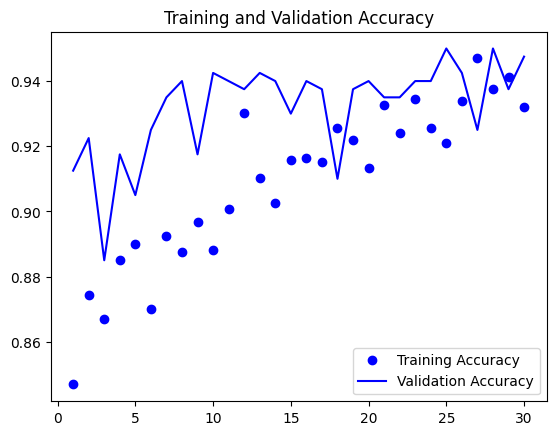

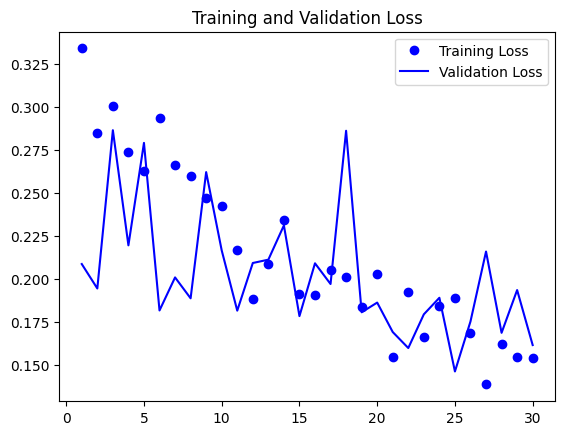

In [3]:
# Transfer Learning + Fine Tuning using VGG16

from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Load pretrained VGG16 convolution base
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

# Build model
model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

# Freeze convolution base
print("Trainable weights before freezing:", len(model.trainable_weights))
conv_base.trainable = False
print("Trainable weights after freezing:", len(model.trainable_weights))


# Dataset directories
#train_dir="/content/cats_dogs_dataset/train/"
#validation_dir="/content/cats_dogs_dataset/validation/"

train_dir="/content/drive/MyDrive/cats_dogs_dataset/cats_dogs_dataset/train/"
validation_dir="/content/drive/MyDrive/cats_dogs_dataset/cats_dogs_dataset/validation/"

# Data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(rescale=1./255)

# Generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

# Compile model (initial training)
model.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=2e-5),
    metrics=['accuracy']
)

# Train top classifier
history = model.fit(
    train_generator,
    #steps_per_epoch=100,
    steps_per_epoch=50,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=50
)

# ------------------------
# Fine Tuning
# ------------------------

conv_base.trainable = True

set_trainable = False
for layer in conv_base.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True
    layer.trainable = set_trainable

# Recompile with lower learning rate
model.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=1e-5),
    metrics=['accuracy']
)

# Fine-tune training
history = model.fit(
    train_generator,
    #steps_per_epoch=100,
    steps_per_epoch=50,
    #epochs=100,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=50
)

# Plot results
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs, acc, 'bo', label='Training Accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()